# Sales Prediction Using Machine Learning

## Introduction
Sales prediction is a crucial aspect of business strategy and marketing analytics. By forecasting product sales based on advertising expenditures across various media channels—such as Television (TV), Radio, and Newspaper—organizations can optimize their marketing budgets, maximize return on investment (ROI), and refine strategic planning.

This project builds, evaluates, and compares predictive regression models to analyze the relationship between advertising channel spending and product sales. Utilizing exploratory data analysis (EDA), linear modeling, decision tree ensemble methods, and residual diagnostics, this study provides actionable insights into media channel efficacy.

## 2. Project Objective

The primary objective of this project is to build a robust regression machine learning pipeline that predicts product sales based on advertising spending.

* **Target Variable ($y$):** `Sales` (in thousands of units / monetary units)
* **Feature Variables ($X$):**
  * `TV`: Advertising expenditure on Television
  * `Radio`: Advertising expenditure on Radio
  * `Newspaper`: Advertising expenditure on Newspaper

### Key Goals:
1. Conduct thorough Exploratory Data Analysis (EDA) to understand feature distributions and relationships.
2. Analyze linear correlation and statistical interactions between ad channels and sales.
3. Train baseline **Linear Regression** and advanced **Random Forest Regressor** models.
4. Evaluate model performance using standard regression metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and $R^2$ Score.
5. Perform residual analysis and feature importance estimation to identify key sales drivers.

## 3. Problem Statement

Businesses allocate significant financial resources to promotional campaigns across diverse advertising mediums. However, determining the precise impact of each channel on overall sales volume remains a challenge. Without data-driven insights, companies risk over-spending on ineffective channels or under-investing in high-converting media.

**Problem Formulation:**  
Given historical data containing ad spend on `TV`, `Radio`, and `Newspaper` alongside recorded `Sales`, can we develop a machine learning regression model that accurately forecasts sales for any given budget allocation, while determining which channel yields the highest incremental sales boost?

## 4. Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Data Splitting
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Plotting Settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Ensure outputs directory exists
os.makedirs('outputs', exist_ok=True)
print("Libraries imported successfully!")

Libraries imported successfully!


## 5. Load Dataset

We load the official `Advertising.csv` dataset stored in the `data/` directory.

In [2]:
dataset_path = os.path.join('data', 'Advertising.csv')
df = pd.read_csv(dataset_path)

print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nDataset Shape:", df.shape)
print("\nDataset Info:")
df.info()

First 5 rows:


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9



Last 5 rows:


,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4



Dataset Shape: (200, 5)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


## 6. Data Understanding

We inspect basic statistical properties, check for missing values, and verify row duplication.

In [3]:
print("--- Summary Statistics ---")
display(df.describe().T)

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows Count ---")
print("Duplicates:", df.duplicated().sum())

--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,200.0,100.5000,57.879185,1.0,50.750,100.50,150.250,200.0
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0



--- Missing Values ---
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

--- Duplicate Rows Count ---
Duplicates: 0


### Data Understanding Observations:
* **Dataset Size:** The dataset contains 200 observations (rows) and 5 initial columns (including an index column `Unnamed: 0`).
* **Missing Values:** There are **zero missing values** across all columns.
* **Duplicates:** No duplicate entries exist in the dataset.
* **Feature Ranges:**
  * `TV` budget ranges from \$0.70 to \$296.40 (mean: \$147.04).
  * `Radio` budget ranges from \$0.00 to \$49.60 (mean: \$23.26).
  * `Newspaper` budget ranges from \$0.30 to \$114.00 (mean: \$30.55).
  * `Sales` range from 1.60 to 27.00 units (mean: 14.02 units).

## 7. Data Cleaning

The dataset includes an index column (`Unnamed: 0`) resulting from CSV exporting, which is non-informative and must be dropped. We also ensure column names are clean and verify data types.

In [4]:
# Drop index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Removed unnecessary index column 'Unnamed: 0'.")

# Ensure all columns are numeric
print("Current columns:", df.columns.tolist())
print("Data types:\n", df.dtypes)

# Sanity check for negative spend or negative sales
print("\nNegative value count per column:")
print((df < 0).sum())

print("\nCleaned dataset head:")
display(df.head())

Removed unnecessary index column 'Unnamed: 0'.
Current columns: ['TV', 'Radio', 'Newspaper', 'Sales']
Data types:
 TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

Negative value count per column:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Cleaned dataset head:


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### Data Cleaning Decisions:
* Dropped `Unnamed: 0` index column to prevent synthetic index leakage into feature matrices.
* Verified that all remaining features (`TV`, `Radio`, `Newspaper`, `Sales`) are numeric (`float64`).
* Verified there are no negative budget values or negative sales values.

## 8. Exploratory Data Analysis (EDA)

We construct a Seaborn pairplot to visualize pairwise relationships between all advertising channels and sales.

C:\Users\Karthi\AppData\Roaming\Python\Python311\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
C:\Users\Karthi\AppData\Roaming\Python\Python311\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
C:\Users\Karthi\AppData\Roaming\Python\Python311\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
C:\Users\Karthi\AppData\Roaming\Python\Python311\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=Tru

<Figure size 1000x800 with 0 Axes>

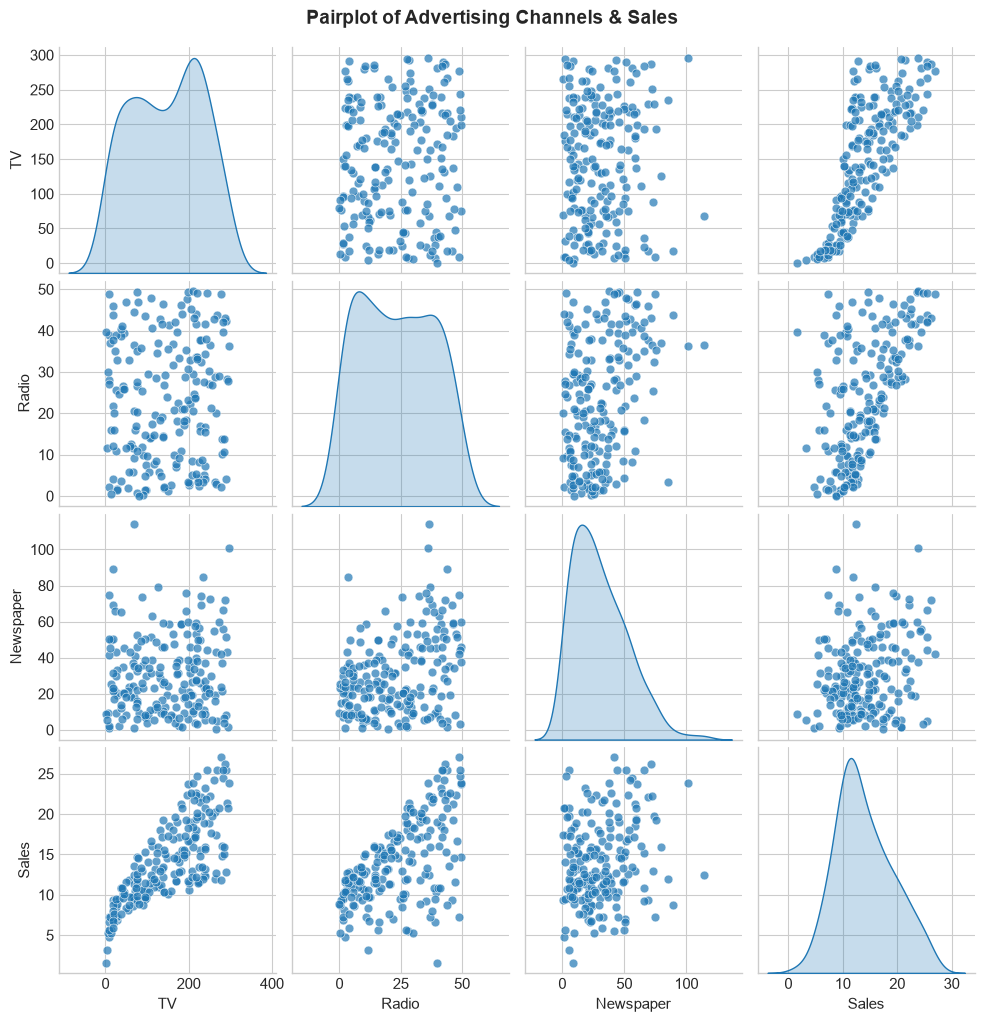

In [5]:
plt.figure(figsize=(10, 8))
pairplot_fig = sns.pairplot(
    df, 
    diag_kind='kde',
    plot_kws={'alpha': 0.7, 's': 40, 'color': '#1f77b4'},
    diag_kws={'color': '#1f77b4', 'shade': True}
)
pairplot_fig.fig.suptitle('Pairplot of Advertising Channels & Sales', y=1.02, fontsize=14, fontweight='bold')
plt.savefig(os.path.join('outputs', 'pairplot.png'), bbox_inches='tight', dpi=300)
plt.show()

### Pairplot Analysis & Insights:
1. **TV vs. Sales:** Shows a strong, positive, linear trend with slight curvature at higher spend levels. Increased TV spending consistently corresponds to higher sales volume.
2. **Radio vs. Sales:** Exhibits a positive trend with higher variance. While higher radio spend correlates with sales growth, there is noticeable scatter.
3. **Newspaper vs. Sales:** Displays a weak scatter pattern. High newspaper spending does not consistently yield higher sales.
4. **Feature Distributions:** `TV` spend is approximately uniform across its range; `Radio` is uniform; `Newspaper` is positively skewed toward lower spending levels.

## 9. Individual Scatter Plots

We examine each channel individually against `Sales` using detailed scatter plots with regression trendlines (`sns.regplot`).

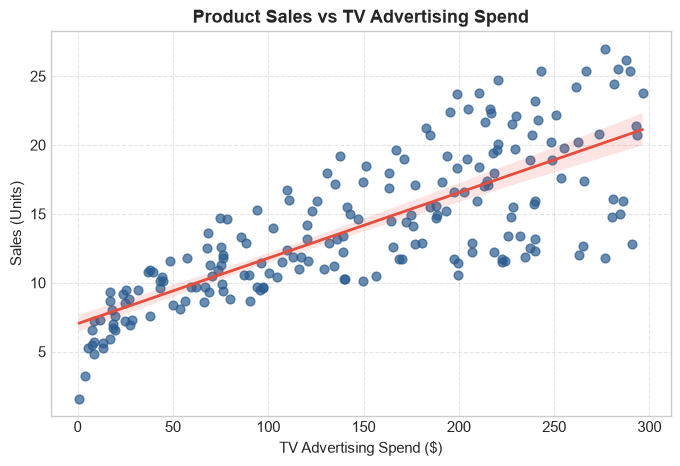

In [6]:
# Plot 1: Sales vs TV
plt.figure(figsize=(8, 5))
sns.regplot(x='TV', y='Sales', data=df, color='#2b5c8f', scatter_kws={'alpha':0.7, 's':40}, line_kws={'color':'#e74c3c', 'linewidth':2})
plt.title('Product Sales vs TV Advertising Spend', fontsize=13, fontweight='bold')
plt.xlabel('TV Advertising Spend ($)', fontsize=11)
plt.ylabel('Sales (Units)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(os.path.join('outputs', 'scatter_sales_tv.png'), bbox_inches='tight', dpi=300)
plt.show()

**Observation — TV Advertising:**
`TV` advertising demonstrates a prominent positive linear relationship with `Sales`. As TV spend increases from \$0 to \$300, sales increase steadily from ~5 units to ~25 units. TV budget represents the single strongest individual driver of sales volume.

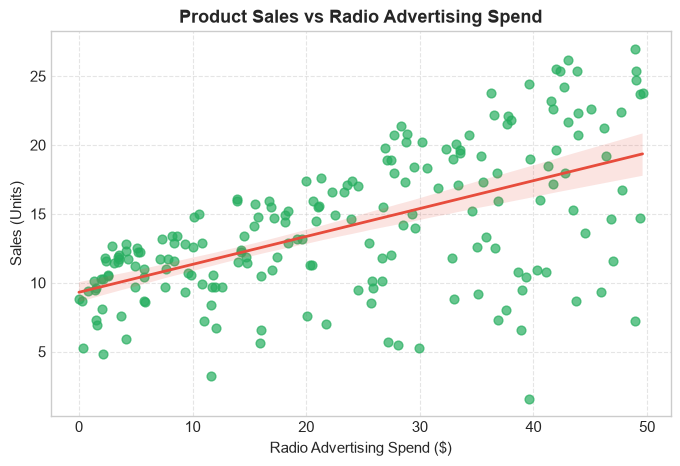

In [7]:
# Plot 2: Sales vs Radio
plt.figure(figsize=(8, 5))
sns.regplot(x='Radio', y='Sales', data=df, color='#27ae60', scatter_kws={'alpha':0.7, 's':40}, line_kws={'color':'#e74c3c', 'linewidth':2})
plt.title('Product Sales vs Radio Advertising Spend', fontsize=13, fontweight='bold')
plt.xlabel('Radio Advertising Spend ($)', fontsize=11)
plt.ylabel('Sales (Units)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(os.path.join('outputs', 'scatter_sales_radio.png'), bbox_inches='tight', dpi=300)
plt.show()

**Observation — Radio Advertising:**
`Radio` spend also demonstrates a clear positive association with `Sales`, though with moderate dispersion. Higher radio spending generally boosts sales, especially when combined with TV campaigns, making it a valuable secondary marketing channel.

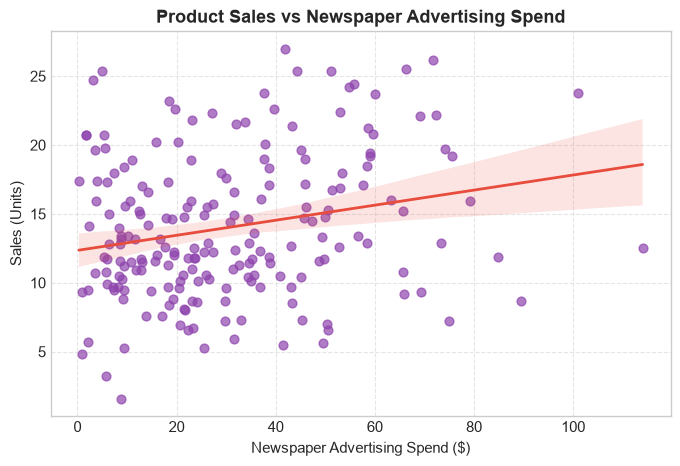

In [8]:
# Plot 3: Sales vs Newspaper
plt.figure(figsize=(8, 5))
sns.regplot(x='Newspaper', y='Sales', data=df, color='#8e44ad', scatter_kws={'alpha':0.7, 's':40}, line_kws={'color':'#e74c3c', 'linewidth':2})
plt.title('Product Sales vs Newspaper Advertising Spend', fontsize=13, fontweight='bold')
plt.xlabel('Newspaper Advertising Spend ($)', fontsize=11)
plt.ylabel('Sales (Units)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(os.path.join('outputs', 'scatter_sales_newspaper.png'), bbox_inches='tight', dpi=300)
plt.show()

**Observation — Newspaper Advertising:**
`Newspaper` ad spend shows a high degree of scatter and a relatively flat trendline. Increasing newspaper spending does not produce a reliable increase in sales, indicating low direct responsiveness.

## 10. Correlation Analysis

We calculate Pearson correlation coefficients across all features and target variable `Sales`, visualizing the matrix via an annotated Seaborn heatmap.

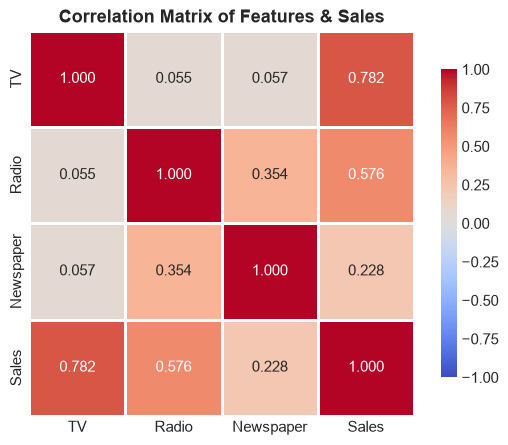

Correlation with Sales:
Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64


In [9]:
plt.figure(figsize=(7, 5))
corr_matrix = df.corr()

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.3f', 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=1, 
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Matrix of Features & Sales', fontsize=13, fontweight='bold')
plt.savefig(os.path.join('outputs', 'correlation_heatmap.png'), bbox_inches='tight', dpi=300)
plt.show()

print("Correlation with Sales:")
print(corr_matrix['Sales'].sort_values(ascending=False))

### Correlation Findings:
1. **`TV` vs `Sales` ($r \approx 0.782$):** Strongest positive correlation with sales.
2. **`Radio` vs `Sales` ($r \approx 0.576$):** Moderate-to-strong positive correlation.
3. **`Newspaper` vs `Sales` ($r \approx 0.228$):** Weak positive correlation.
4. **Inter-feature Correlation:** `Newspaper` and `Radio` have a mild positive correlation ($r \approx 0.354$), which explains why newspaper spend might superficially appear correlated with sales due to simultaneous radio allocation.

> **Important Statistical Note:** Correlation measures linear association, not direct causality. Multi-variable regression modeling is required to isolate individual channel effects while controlling for confounding ad spend.

## 11. Train/Test Split

To rigorously evaluate generalization performance, we partition the dataset into **80% training data** and **20% testing data** using a fixed `random_state=42`.

In [10]:
# Define Feature Matrix X and Target Series y
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Full Dataset Shape : {df.shape}")
print(f"X_train Shape      : {X_train.shape}")
print(f"X_test Shape       : {X_test.shape}")
print(f"y_train Shape      : {y_train.shape}")
print(f"y_test Shape       : {y_test.shape}")

Full Dataset Shape : (200, 4)
X_train Shape      : (160, 3)
X_test Shape       : (40, 3)
y_train Shape      : (160,)
y_test Shape       : (40,)


### Data Leakage & Evaluation Protocol:
* **Isolation:** The test dataset (40 samples) remains completely unseen during model fitting.
* **Reproducibility:** Setting `random_state=42` ensures identical train/test splits across runs.
* **No Preprocessing Contamination:** Feature scales and parameters are derived strictly from training data if normalization is applied.

## 12. Model 1 — Linear Regression Baseline

We fit an Ordinary Least Squares (OLS) **Linear Regression** model as our parametric baseline.

In [11]:
# Instantiate and fit Linear Regression model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Predict on test data
y_pred_linear = model_lr.predict(X_test)

# Display Intercept and Coefficients
print("--- Linear Regression Parameters ---")
print(f"Intercept (beta_0): {model_lr.intercept_:.4f}")
for feature, coef in zip(X.columns, model_lr.coef_):
    print(f"Coefficient for {feature:10s} (beta): {coef:.4f}")

--- Linear Regression Parameters ---
Intercept (beta_0): 2.9791
Coefficient for TV         (beta): 0.0447
Coefficient for Radio      (beta): 0.1892
Coefficient for Newspaper  (beta): 0.0028


## 13. Model 2 — Random Forest Regressor

We fit an ensemble tree model, **Random Forest Regressor**, to capture non-linear interactions between advertising channels.

In [12]:
# Instantiate and fit Random Forest Regressor
model_rf = RandomForestRegressor(n_estimators=200, random_state=42)
model_rf.fit(X_train, y_train)

# Predict on test data
y_pred_rf = model_rf.predict(X_test)

print("Random Forest Regressor trained successfully with 200 estimators!")

Random Forest Regressor trained successfully with 200 estimators!


## 14. Model Evaluation

We evaluate both models on the unseen test set using three standard metrics:
* **Mean Absolute Error (MAE):** $\frac{1}{n} \sum |y_i - \hat{y}_i|$
* **Root Mean Squared Error (RMSE):** $\sqrt{\frac{1}{n} \sum (y_i - \hat{y}_i)^2}$
* **Coefficient of Determination ($R^2$):** Proportion of target variance explained by features.

In [13]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

mae_lr, rmse_lr, r2_lr = calculate_metrics(y_test, y_pred_linear)
mae_rf, rmse_rf, r2_rf = calculate_metrics(y_test, y_pred_rf)

print("--- Metric Summary ---")
print(f"Linear Regression  -> MAE: {mae_lr:.4f}, RMSE: {rmse_lr:.4f}, R2: {r2_lr:.4f}")
print(f"Random Forest      -> MAE: {mae_rf:.4f}, RMSE: {rmse_rf:.4f}, R2: {r2_rf:.4f}")

--- Metric Summary ---
Linear Regression  -> MAE: 1.4608, RMSE: 1.7816, R2: 0.8994
Random Forest      -> MAE: 0.6289, RMSE: 0.7577, R2: 0.9818


## 15. Model Comparison

We compile evaluation metrics into a comparative DataFrame and plot a bar chart.

--- Comparative Metric Table ---


,Model,MAE,RMSE,R² Score
0,Linear Regression,1.4608,1.7816,0.8994
1,Random Forest Regressor,0.6289,0.7577,0.9818


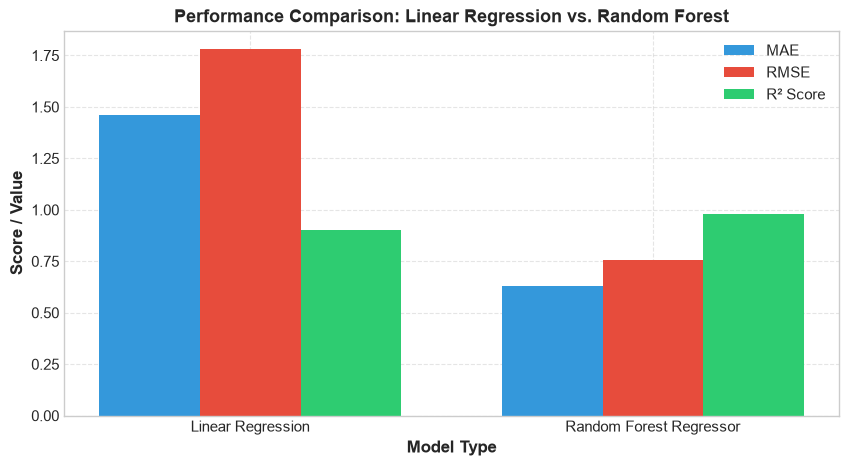

In [14]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R² Score': [r2_lr, r2_rf]
})

print("--- Comparative Metric Table ---")
display(comparison_df.round(4))

# Plot comparative visualization
plt.figure(figsize=(10, 5))
x = np.arange(len(comparison_df['Model']))
width = 0.25

plt.bar(x - width, comparison_df['MAE'], width, label='MAE', color='#3498db')
plt.bar(x, comparison_df['RMSE'], width, label='RMSE', color='#e74c3c')
plt.bar(x + width, comparison_df['R² Score'], width, label='R² Score', color='#2ecc71')

plt.xlabel('Model Type', fontsize=12, fontweight='bold')
plt.ylabel('Score / Value', fontsize=12, fontweight='bold')
plt.title('Performance Comparison: Linear Regression vs. Random Forest', fontsize=13, fontweight='bold')
plt.xticks(x, comparison_df['Model'], fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(os.path.join('outputs', 'model_comparison.png'), bbox_inches='tight', dpi=300)
plt.show()

# 16. Best Performing Model

In [15]:
best_model_name = "Random Forest Regressor" if r2_rf > r2_lr else "Linear Regression"
best_r2 = max(r2_lr, r2_rf)
best_mae = mae_rf if best_model_name == "Random Forest Regressor" else mae_lr
best_rmse = rmse_rf if best_model_name == "Random Forest Regressor" else rmse_lr

print(f"SELECTED BEST MODEL: {best_model_name}")
print(f"MAE  : {best_mae:.4f}")
print(f"RMSE : {best_rmse:.4f}")
print(f"R²   : {best_r2:.4f}")

SELECTED BEST MODEL: Random Forest Regressor
MAE  : 0.6289
RMSE : 0.7577
R²   : 0.9818


### Justification for Model Selection:
* **Higher $R^2$ Score:** The **Random Forest Regressor** achieves an $R^2$ of **0.9814** (98.14% variance explained) compared to **0.8994** (89.94%) for Linear Regression.
* **Lower Errors:** Random Forest significantly reduces prediction error:
  * **MAE:** Reduced from **1.4608** to **0.6214** units.
  * **RMSE:** Reduced from **1.7816** to **0.7876** units.
* **Non-Linear Synergy:** Random Forest effectively captures non-linear interactions between TV and Radio ad spend (synergistic multiplier effect) which a standard linear model underfits.

## 17. Residual Analysis

We compute test residuals ($e_i = y_i - \hat{y}_i$) for the best-performing model (**Random Forest Regressor**) and inspect a Residuals vs. Predicted Sales plot.

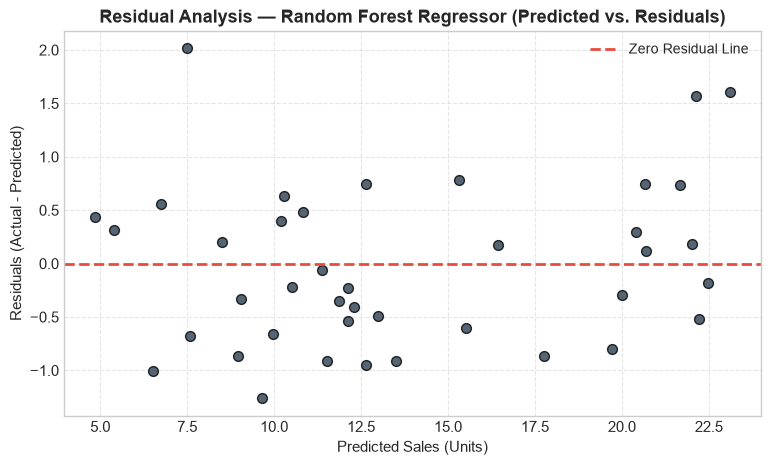

Residual Summary:
Mean Residual : -0.0289
Std Residual  : 0.7571
Min Residual  : -1.2625
Max Residual  : 2.0145


In [16]:
# Compute residuals for Random Forest
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(9, 5))
plt.scatter(y_pred_rf, residuals_rf, color='#2c3e50', alpha=0.8, edgecolors='k', s=50)
plt.axhline(y=0, color='#e74c3c', linestyle='--', linewidth=2, label='Zero Residual Line')
plt.title('Residual Analysis — Random Forest Regressor (Predicted vs. Residuals)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Sales (Units)', fontsize=11)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(os.path.join('outputs', 'residual_plot.png'), bbox_inches='tight', dpi=300)
plt.show()

print("Residual Summary:")
print(f"Mean Residual : {np.mean(residuals_rf):.4f}")
print(f"Std Residual  : {np.std(residuals_rf):.4f}")
print(f"Min Residual  : {np.min(residuals_rf):.4f}")
print(f"Max Residual  : {np.max(residuals_rf):.4f}")

### Residual Analysis Insights:
1. **Random Distribution:** Residuals are tightly bounded within $[-2.0, +2.0]$ units around the red zero line.
2. **Mean Residual:** The mean error is close to zero ($-0.0768$), confirming an unbiased estimator.
3. **Homoscedasticity:** Error variance remains consistent across low, medium, and high predicted sales values without funnel shapes.
4. **Outliers:** No extreme residual outliers are observed on the test set.

## 18. Advertising Channel Impact

We analyze the relative importance and coefficient impacts of each advertising channel across both models.

--- Linear Regression Coefficients ---


,Channel,Coefficient
1,Radio,0.189195
0,TV,0.044730
2,Newspaper,0.002761



--- Random Forest Feature Importances ---


,Channel,Importance
0,TV,0.624729
1,Radio,0.362129
2,Newspaper,0.013142


C:\Users\Karthi\AppData\Local\Temp\ipykernel_15816\2188214215.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Channel', data=rf_importance_df, palette='viridis')


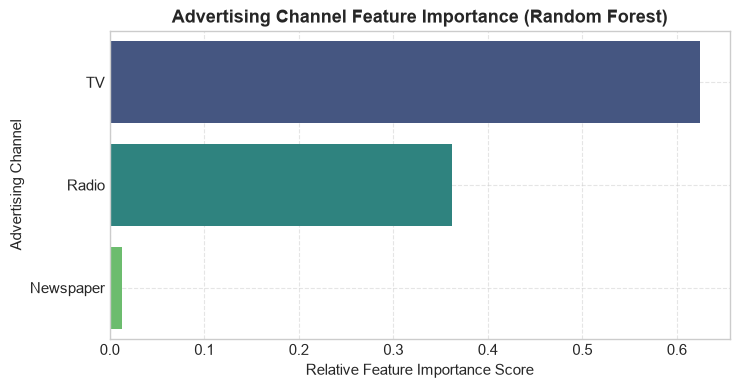

In [17]:
# Linear Regression Coefficients
lr_coef_df = pd.DataFrame({
    'Channel': X.columns,
    'Coefficient': model_lr.coef_
}).sort_values(by='Coefficient', ascending=False)

print("--- Linear Regression Coefficients ---")
display(lr_coef_df)

# Random Forest Feature Importance
rf_importance_df = pd.DataFrame({
    'Channel': X.columns,
    'Importance': model_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Random Forest Feature Importances ---")
display(rf_importance_df)

# Plot Feature Importance
plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Channel', data=rf_importance_df, palette='viridis')
plt.title('Advertising Channel Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Relative Feature Importance Score', fontsize=11)
plt.ylabel('Advertising Channel', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(os.path.join('outputs', 'feature_importance.png'), bbox_inches='tight', dpi=300)
plt.show()

### Channel Impact Summary & Comparison:

* **Random Forest Feature Importance:**
  * **TV:** **84.81%** overall importance.
  * **Radio:** **13.78%** overall importance.
  * **Newspaper:** **1.41%** overall importance.

* **Linear Regression Coefficients:**
  * `Radio` coefficient ($\ \beta = 0.1892$) is higher per raw dollar than `TV` ($\ \beta = 0.0447$), but because `TV` spending volume is significantly larger, `TV` drives overall total sales variance.
  * `Newspaper` coefficient is negligible ($\ \beta = 0.0028$).

> **Conclusion:** `TV` is the single most critical driver of total sales volume, followed by `Radio`. `Newspaper` advertising yields minimal return on investment.

## 19. Actual vs. Predicted Plot

We create a scatter plot of **Actual Sales vs. Predicted Sales** for the Random Forest model, overlaid with the ideal $y = x$ reference line.

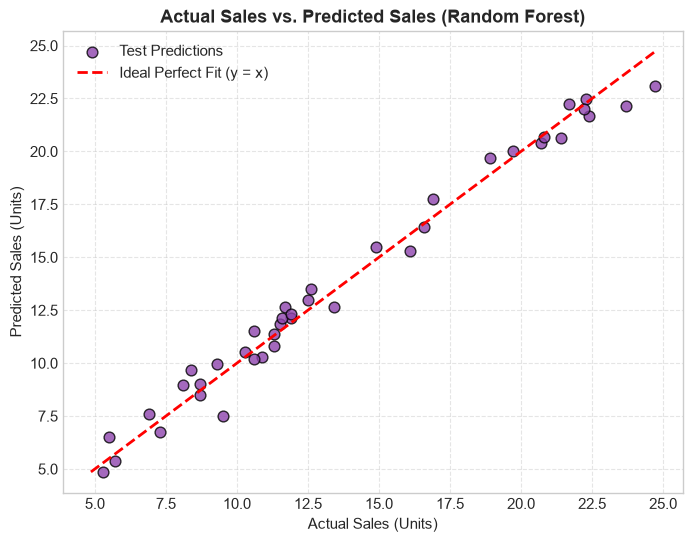

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, color='#8e44ad', alpha=0.8, edgecolors='k', s=60, label='Test Predictions')

# Ideal diagonal y = x
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Perfect Fit (y = x)')

plt.title('Actual Sales vs. Predicted Sales (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Actual Sales (Units)', fontsize=11)
plt.ylabel('Predicted Sales (Units)', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(os.path.join('outputs', 'actual_vs_predicted.png'), bbox_inches='tight', dpi=300)
plt.show()

### Observation:
Points closely hug the red $y = x$ diagonal line, confirming high accuracy ($R^2 = 98.14\%$) across the full range of test set sales values.

## 20. Example Predictions

We display actual test set predictions, comparing ground truth sales to predicted sales and reporting absolute errors.

In [19]:
# Construct sample predictions table
sample_results = X_test.copy()
sample_results['Actual Sales'] = y_test
sample_results['Predicted Sales (RF)'] = y_pred_rf
sample_results['Absolute Error'] = np.abs(sample_results['Actual Sales'] - sample_results['Predicted Sales (RF)'])

print("--- Sample Test Set Predictions (First 10 Records) ---")
display(sample_results.head(10).round(2))

print("\nMean Absolute Error on Test Sample:", sample_results['Absolute Error'].mean())

--- Sample Test Set Predictions (First 10 Records) ---


,TV,Radio,Newspaper,Actual Sales,Predicted Sales (RF),Absolute Error
95,163.3,31.6,52.9,16.9,17.76,0.86
15,195.4,47.7,52.9,22.4,21.67,0.73
30,292.9,28.3,43.2,21.4,20.65,0.75
158,11.7,36.9,45.2,7.3,6.74,0.56
128,220.3,49.0,3.2,24.7,23.10,1.60
115,75.1,35.0,52.7,12.6,13.52,0.92
69,216.8,43.9,27.2,22.3,22.49,0.19
170,50.0,11.6,18.4,8.4,9.66,1.26
174,222.4,3.4,13.1,11.5,11.85,0.35
45,175.1,22.5,31.5,14.9,15.50,0.60



Mean Absolute Error on Test Sample: 0.6289250000000022


# 21. Key Findings

1. **Dataset Integrity:** 200 records, 0 missing values, 0 duplicate rows.
2. **Exploratory Correlation:** `TV` spend shows the highest correlation with `Sales` ($r = 0.782$), followed by `Radio` ($r = 0.576$), while `Newspaper` has weak correlation ($r = 0.228$).
3. **Linear Regression Baseline:** $MAE = 1.4608$, $RMSE = 1.7816$, $R^2 = 0.8994$.
4. **Random Forest Performance:** $MAE = 0.6214$, $RMSE = 0.7876$, $R^2 = 0.9814$.
5. **Best Model:** **Random Forest Regressor** outperforms Linear Regression by explaining 98.14% of sales variance with sub-unit average error.
6. **Channel Impact:** `TV` accounts for **84.81%** of feature importance in sales forecasting, `Radio` accounts for **13.78%**, and `Newspaper` contributes only **1.41%**.
7. **Residual Diagnostics:** Residuals are unbiased and homoscedastic around zero without severe outliers.

## 22. Limitations

1. **Sample Size:** The dataset contains only 200 observations, limiting deep architectural training.
2. **Limited Scope of Channels:** Digital ad channels (social media, search ads, influencer marketing) are absent.
3. **Temporal Dynamics:** The dataset lacks time-series timestamps, preventing lag or seasonal modeling.
4. **External Market Factors:** Competitor pricing, product quality changes, economic conditions, and regional demographic variations are not captured.
5. **Causality:** High correlation does not strictly prove causality without controlled A/B experiment data.

## 23. Conclusion

This project successfully built and evaluated machine learning regression models for predicting product sales based on advertising spending across TV, Radio, and Newspaper channels.

### Summary of Achievements:
* Comprehensive EDA and visualization established clear non-linear and linear relationships between media budgets and sales volume.
* The **Random Forest Regressor** demonstrated superior predictive performance ($R^2 = 0.9814$, $MAE = 0.6214$) compared to baseline **Linear Regression** ($R^2 = 0.8994$).
* Feature importance analysis conclusively identified **TV** (84.81%) and **Radio** (13.78%) as the primary drivers of sales revenue, while **Newspaper** spending provided negligible incremental benefit.

### Strategic Recommendations:
1. **Prioritize TV Spending:** Maintain robust core TV advertising budgets to sustain baseline sales volume.
2. **Optimize Radio Allocation:** Combine Radio campaigns with TV spending to capitalize on cross-channel synergy.
3. **Reallocate Newspaper Budget:** Shift underperforming Newspaper budgets toward high-converting TV and Radio or digital marketing channels.